In [1]:
#import and formatting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import itertools

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.size'] = 12
sns.set(style="whitegrid", context="talk")

file_path = "Source_Data_CXCL12_placenta.xlsx"
df = pd.read_excel(file_path, sheet_name="Fig_4D")  

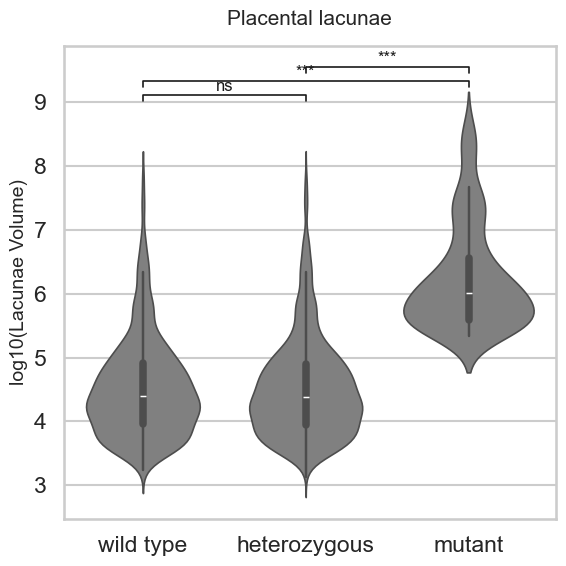

In [2]:
genotypes = df.iloc[0].values

data_values = df.iloc[1:].values

data_list = []
for col_idx, genotype in enumerate(genotypes):
    for value in data_values[:, col_idx]:
        if pd.notna(value):  # skip NaN values
            data_list.append({
                'Condition': genotype,
                'Value': value
            })

data = pd.DataFrame(data_list)

data['Value'] = pd.to_numeric(data['Value'], errors='coerce')
data = data.dropna(subset=['Value'])
data = data[data['Value'] > 0] 

# log transformation
data['LogValue'] = np.log10(data['Value'].astype(float))


genotype_order = ["wild type", "heterozygous", "mutant"]

plt.figure(figsize=(6, 6))
ax = sns.violinplot(
    x='Condition', y='LogValue', data=data,
    order=genotype_order,
    color='gray', linewidth=1.2
)

conditions = genotype_order 
comparisons = list(itertools.combinations(conditions, 2))

y_max = data['LogValue'].max()
y_offset = (y_max - data['LogValue'].min()) * 0.08
height = y_max + y_offset

for i, (cond1, cond2) in enumerate(comparisons):
    vals1 = data.loc[data['Condition'] == cond1, 'LogValue']
    vals2 = data.loc[data['Condition'] == cond2, 'LogValue']
    stat, p = mannwhitneyu(vals1, vals2, alternative='two-sided')
    
    # Significance stars
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    else:
        stars = 'ns'
    
    # Plot the lines and annotations
    x1, x2 = conditions.index(cond1), conditions.index(cond2)
    ax.plot([x1, x1, x2, x2],
            [height, height + y_offset*0.2, height + y_offset*0.2, height],
            lw=1.2, c='k')
    ax.text((x1 + x2)/2, height + y_offset*0.25, stars,
            ha='center', va='bottom', color='k', fontsize=12)
    height += y_offset * 0.5

ax.set_ylabel('log10(Lacunae Volume)', fontsize=14)
ax.set_xlabel('')
plt.title('Placental lacunae', fontsize=15, pad=15)
plt.tight_layout()
plt.show()